In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.manifold import TSNE
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from scipy.stats import f_oneway
import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs('plots', exist_ok=True)
os.makedirs('data', exist_ok=True)

print("Libraries loaded")

X_scaled = pd.read_csv('data/X_scaled.csv')
X_pca_2d = pd.read_csv('data/X_pca_2d.csv')
exam_scores = pd.read_csv('data/exam_scores.csv').squeeze()
df_encoded = pd.read_csv('data/student_preprocessed.csv')
X_array = np.array(X_scaled)

print(f"X_scaled shape: {X_scaled.shape}")
print(f"X_pca_2d shape: {X_pca_2d.shape}")
print("Data loaded")

Libraries loaded
X_scaled shape: (6607, 21)
X_pca_2d shape: (6607, 2)
Data loaded


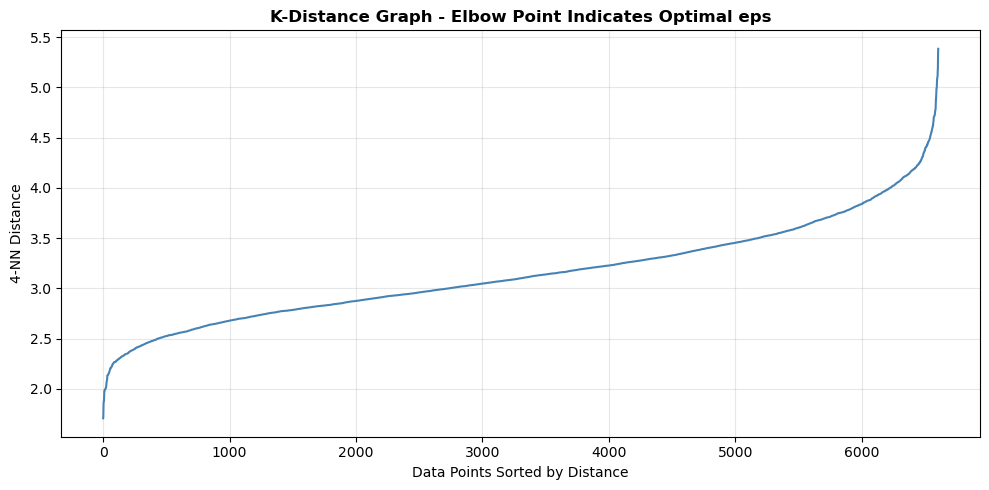

Distance percentiles:
  50th: 3.1012
  75th: 3.4439
  85th: 3.6575
  90th: 3.8114
  95th: 4.0483

No sharp elbow observed. data has uniform density distribution
eps selected at curve acceleration point (~4.0)


In [2]:
# k-distance graph to determine optimal eps
# rule of thumb: k = min_samples value we plan to use
k = 4
neigh = NearestNeighbors(n_neighbors=k)
neigh.fit(X_array)
distances, _ = neigh.kneighbors(X_array)
k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(10, 5))
plt.plot(k_distances, linewidth=1.5, color='steelblue')
plt.xlabel('Data Points Sorted by Distance')
plt.ylabel(f'{k}-NN Distance')
plt.title('K-Distance Graph - Elbow Point Indicates Optimal eps',
          fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/dbscan_kdistance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Distance percentiles:")
print(f"  50th: {np.percentile(k_distances, 50):.4f}")
print(f"  75th: {np.percentile(k_distances, 75):.4f}")
print(f"  85th: {np.percentile(k_distances, 85):.4f}")
print(f"  90th: {np.percentile(k_distances, 90):.4f}")
print(f"  95th: {np.percentile(k_distances, 95):.4f}")
print("\nNo sharp elbow observed. data has uniform density distribution")
print("eps selected at curve acceleration point (~4.0)")

In [3]:
# systematic parameter search to find best eps and min_samples
# degenerate results (imbalance > 100x) are skipped

eps_values = [3.0, 3.5, 4.0, 4.5]
min_samples_values = [3, 4, 5, 6, 8, 10]

results = []

print("eps\tmin_s\tn_clusters\tn_noise\tnoise%\timbalance\tsilhouette\tDB\tCH")
print("-" * 105)

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_array)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        noise_ratio = n_noise / len(labels) * 100

        if n_clusters >= 2:
            dist = pd.Series(labels[labels != -1]).value_counts()
            imbalance = dist.max() / dist.min()

            if imbalance > 100:
                print(f"{eps}\t{min_samples}\t\t{n_clusters}\t\t{n_noise}\t{noise_ratio:.1f}%\t{imbalance:.0f}x\t\tDegenerate")
                continue

            sil = silhouette_score(X_array, labels, sample_size=2000, random_state=42)
            db  = davies_bouldin_score(X_array, labels)
            ch  = calinski_harabasz_score(X_array, labels)

            results.append({
                'eps': eps, 'min_samples': min_samples,
                'n_clusters': n_clusters, 'n_noise': int(n_noise),
                'noise_ratio': round(noise_ratio, 2),
                'imbalance': round(imbalance, 1),
                'silhouette': round(sil, 4),
                'davies_bouldin': round(db, 4),
                'calinski_harabasz': round(ch, 1)
            })
            print(f"{eps}\t{min_samples}\t\t{n_clusters}\t\t{n_noise}\t{noise_ratio:.1f}%\t{imbalance:.1f}x\t\t{sil:.4f}\t\t{db:.4f}\t{ch:.1f}")
        else:
            print(f"{eps}\t{min_samples}\t\t{n_clusters}\t\t{n_noise}\t{noise_ratio:.1f}%\t-\t\tN/A")

results_df = pd.DataFrame(results)
print(f"\nValid balanced configurations: {len(results_df)}")
print("\nConclusion: No balanced configurations found across all parameter combinations.")
print("DBSCAN is not suitable for this dataset due to uniform density distribution.")
print("Best available result: eps=4.0, min_samples=4 (documented for comparison)")

eps	min_s	n_clusters	n_noise	noise%	imbalance	silhouette	DB	CH
---------------------------------------------------------------------------------------------------------
3.0	3		61		2317	35.1%	565x		Degenerate
3.0	4		27		2632	39.8%	811x		Degenerate
3.0	5		14		2899	43.9%	784x		Degenerate
3.0	6		8		3117	47.2%	301x		Degenerate
3.0	8		5		3487	52.8%	197x		Degenerate
3.0	10		4		3866	58.5%	250x		Degenerate
3.5	3		12		664	10.0%	1892x		Degenerate
3.5	4		5		764	11.6%	1874x		Degenerate
3.5	5		11		850	12.9%	1376x		Degenerate
3.5	6		9		976	14.8%	1086x		Degenerate
3.5	8		5		1135	17.2%	763x		Degenerate
3.5	10		5		1290	19.5%	746x		Degenerate
4.0	3		5		119	1.8%	2157x		Degenerate
4.0	4		3		139	2.1%	1615x		Degenerate
4.0	5		1		158	2.4%	-		N/A
4.0	6		1		176	2.7%	-		N/A
4.0	8		3		213	3.2%	1596x		Degenerate
4.0	10		1		257	3.9%	-		N/A
4.5	3		1		19	0.3%	-		N/A
4.5	4		1		23	0.3%	-		N/A
4.5	5		1		24	0.4%	-		N/A
4.5	6		1		27	0.4%	-		N/A
4.5	8		1		31	0.5%	-		N/A
4.5	10		1		39	0.6%	-		N/A

Valid balanced configurati

In [4]:
# eps=4.0, min_samples=4 selected as best available configuration
# note: all configurations either produced degenerate clusters or excessive noise
# this is documented as a limitation of DBSCAN on this dataset

EPS = 4.0
MIN_SAMPLES = 4

dbscan_final = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
cluster_labels = dbscan_final.fit_predict(X_array)

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = (cluster_labels == -1).sum()
noise_ratio = n_noise / len(cluster_labels) * 100

print(f"DBSCAN fitted: eps={EPS}, min_samples={MIN_SAMPLES} ✓")
print(f"Clusters found: {n_clusters}")
print(f"Noise points:   {n_noise} ({noise_ratio:.1f}%)")
print(f"\nCluster distribution:")
print(pd.Series(cluster_labels).value_counts().sort_index())

# check imbalance
valid_labels = cluster_labels[cluster_labels != -1]
if len(np.unique(valid_labels)) >= 2:
    dist = pd.Series(valid_labels).value_counts()
    print(f"\nImbalance ratio: {dist.max()/dist.min():.1f}x")
    print("Note: severely imbalanced. DBSCAN unsuitable for this dataset")

DBSCAN fitted: eps=4.0, min_samples=4 ✓
Clusters found: 3
Noise points:   139 (2.1%)

Cluster distribution:
-1     139
 0    6460
 1       4
 2       4
dtype: int64

Imbalance ratio: 1615.0x
Note: severely imbalanced. DBSCAN unsuitable for this dataset


In [5]:
from scipy.stats import f_oneway

mask = cluster_labels != -1
unique_valid = np.unique(cluster_labels[mask])
dist = pd.Series(cluster_labels[mask]).value_counts().sort_index()

print(f"Unique clusters (excluding noise): {unique_valid}")
print(f"Cluster sizes:\n{dist}")

# to check if any cluster is too small for metrics
min_cluster_size = dist.min()
print(f"Smallest cluster: {min_cluster_size} students")

if len(unique_valid) >= 2 and min_cluster_size >= 10:
    sil = silhouette_score(X_array[mask], cluster_labels[mask])  # no sample_size
    db  = davies_bouldin_score(X_array[mask], cluster_labels[mask])
    ch  = calinski_harabasz_score(X_array[mask], cluster_labels[mask])

    df_encoded['Cluster'] = cluster_labels
    df_encoded['Exam_Score'] = exam_scores.values
    df_clean = df_encoded[df_encoded['Cluster'] != -1]
    groups = [g['Exam_Score'].values for _, g in df_clean.groupby('Cluster')]
    f_stat, p_value = f_oneway(*groups)

    print("\n=== DBSCAN EVALUATION ===")
    print(f"eps:                      {EPS}")
    print(f"min_samples:              {MIN_SAMPLES}")
    print(f"n_clusters:               {n_clusters}")
    print(f"Noise Points:             {n_noise} ({noise_ratio:.1f}%)")
    print(f"Silhouette Score:         {sil:.4f}")
    print(f"Davies-Bouldin Index:     {db:.4f}")
    print(f"Calinski-Harabasz Score:  {ch:.1f}")
    print(f"ANOVA F-statistic:        {f_stat:.4f}")
    print(f"ANOVA p-value:            {p_value:.6f}")

    sil_r, db_r, ch_r = round(sil,4), round(db,4), round(ch,1)
    fstat_r, pval_r = round(f_stat,4), round(p_value,6)

else:
    print("\nClusters too small or insufficient - metrics cannot be computed")
    print("Confirms DBSCAN is unsuitable for this dataset")
    print("Documenting as limitation")
    sil_r = db_r = ch_r = fstat_r = pval_r = 'N/A'

metrics = {
    'Model': 'DBSCAN',
    'eps': EPS,
    'min_samples': MIN_SAMPLES,
    'n_clusters': n_clusters,
    'Noise Points': int(n_noise),
    'Silhouette Score': sil_r,
    'Davies-Bouldin Index': db_r,
    'Calinski-Harabasz Score': ch_r,
    'ANOVA F-statistic': fstat_r,
    'ANOVA p-value': pval_r
}
pd.DataFrame([metrics]).to_csv('data/metrics_dbscan.csv', index=False)
print("\nMetrics saved to data/metrics_dbscan.csv")

Unique clusters (excluding noise): [0 1 2]
Cluster sizes:
0    6460
1       4
2       4
dtype: int64
Smallest cluster: 4 students

Clusters too small or insufficient - metrics cannot be computed
Confirms DBSCAN is unsuitable for this dataset
Documenting as limitation

Metrics saved to data/metrics_dbscan.csv


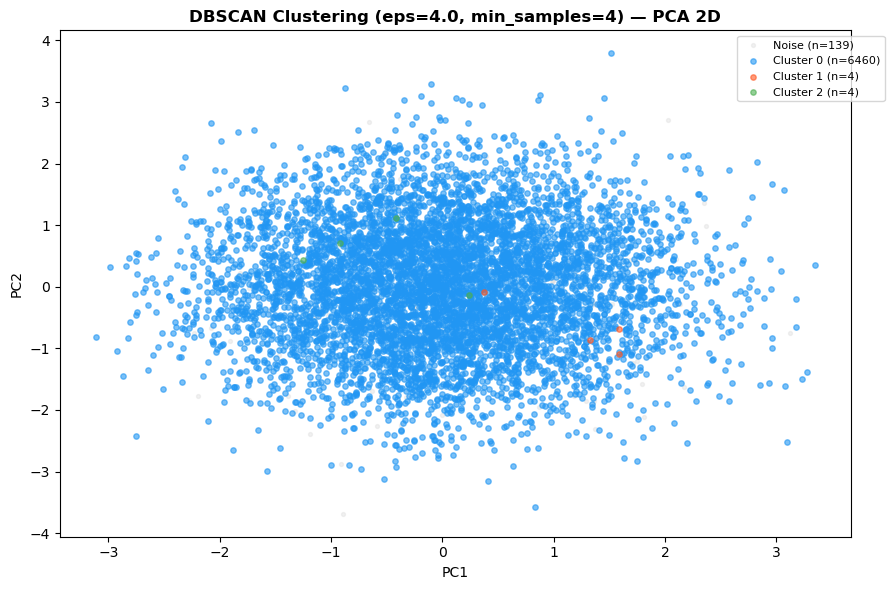

In [6]:
palette = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']

plt.figure(figsize=(9, 6))

noise_mask = cluster_labels == -1
plt.scatter(X_pca_2d.loc[noise_mask, 'PC1'],
            X_pca_2d.loc[noise_mask, 'PC2'],
            c='lightgrey', s=8, alpha=0.3,
            label=f'Noise (n={noise_mask.sum()})')

for cluster_id in sorted(set(cluster_labels) - {-1}):
    mask = cluster_labels == cluster_id
    plt.scatter(X_pca_2d.loc[mask, 'PC1'],
                X_pca_2d.loc[mask, 'PC2'],
                label=f'Cluster {cluster_id} (n={mask.sum()})',
                alpha=0.6, s=15,
                color=palette[cluster_id % len(palette)])

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'DBSCAN Clustering (eps={EPS}, min_samples={MIN_SAMPLES}) — PCA 2D',
          fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), fontsize=8)
plt.tight_layout()
plt.savefig('plots/dbscan_pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

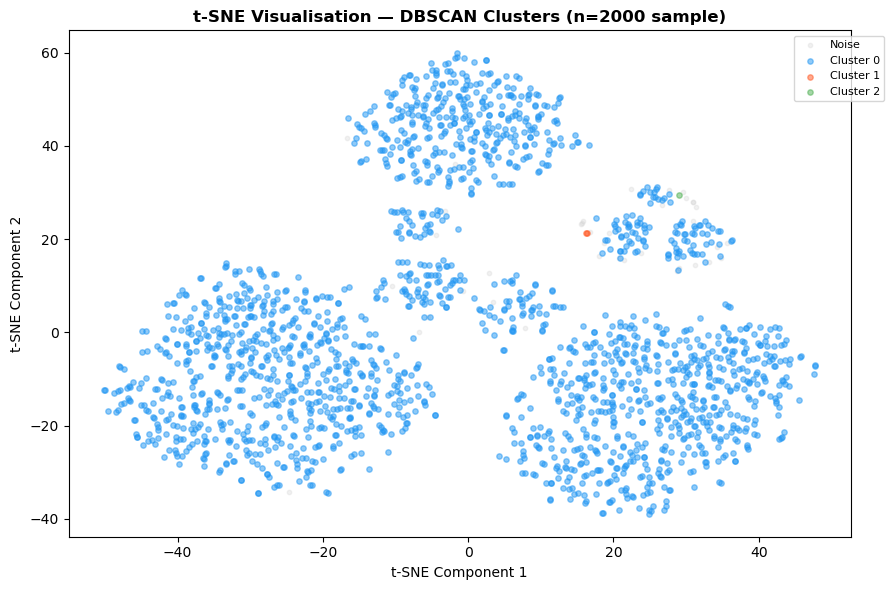

In [7]:
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=2000, replace=False)
X_sample = X_array[sample_idx]
labels_sample = cluster_labels[sample_idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(9, 6))
noise_mask_s = labels_sample == -1
plt.scatter(X_tsne[noise_mask_s, 0], X_tsne[noise_mask_s, 1],
            c='lightgrey', s=10, alpha=0.3, label='Noise')

for cluster_id in sorted(set(labels_sample) - {-1}):
    mask = labels_sample == cluster_id
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                label=f'Cluster {cluster_id}',
                alpha=0.5, s=15,
                color=palette[cluster_id % len(palette)])

plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE Visualisation — DBSCAN Clusters (n=2000 sample)',
          fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), fontsize=8)
plt.tight_layout()
plt.savefig('plots/dbscan_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

=== CLUSTER PROFILES (excluding noise) ===
Cluster                    0      1      2
Hours_Studied          19.98  20.25  17.75
Attendance             80.02  86.00  72.50
Previous_Scores        75.01  58.25  83.25
Exam_Score             67.25  67.25  61.75
Tutoring_Sessions       1.48   2.75   0.50
Sleep_Hours             7.03   7.75   5.25
Physical_Activity       2.96   3.00   3.25
Motivation_Level        0.91   1.75   0.25
Access_to_Resources     1.10   1.25   1.00
Parental_Involvement    1.09   1.25   1.00
Family_Income           0.79   1.25   0.50
Learning_Disabilities   0.09   1.00   1.00


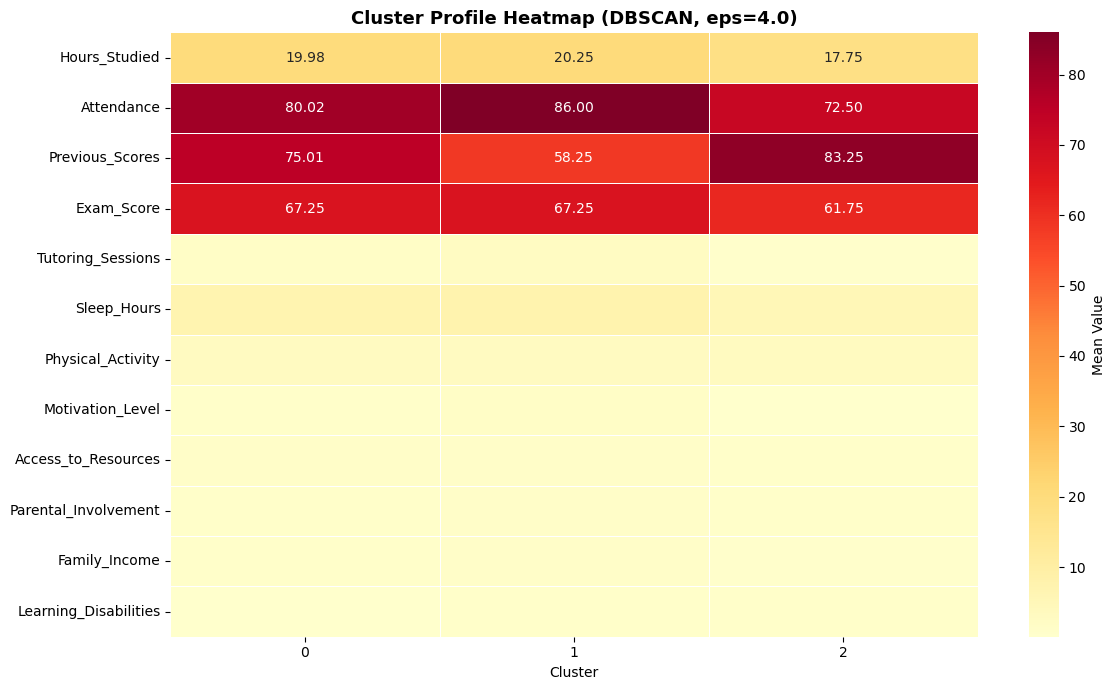

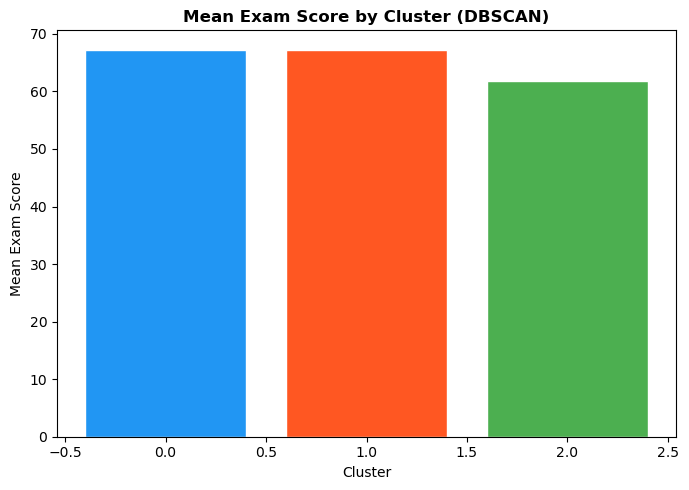


=== LEARNING DISABILITIES PER CLUSTER ===
Cluster
-1    0.561
 0    0.094
 1    1.000
 2    1.000
Name: Learning_Disabilities, dtype: float64
Cluster
-1     139
 0    6460
 1       4
 2       4
dtype: int64


In [8]:
# assign cluster labels to df_encoded (in case Cell 6 went to else branch)
df_encoded['Cluster'] = cluster_labels
df_encoded['Exam_Score'] = exam_scores.values

profile_cols = [
    'Hours_Studied', 'Attendance', 'Previous_Scores', 'Exam_Score',
    'Tutoring_Sessions', 'Sleep_Hours', 'Physical_Activity',
    'Motivation_Level', 'Access_to_Resources', 'Parental_Involvement',
    'Family_Income', 'Learning_Disabilities'
]

df_clean = df_encoded[df_encoded['Cluster'] != -1]

if len(df_clean) == 0 or df_clean['Cluster'].nunique() < 2:
    print("No valid clusters to profile — DBSCAN unsuitable for this dataset")
    print("Skipping profiling as per tutor guidance")
else:
    profile = df_clean.groupby('Cluster')[profile_cols].mean().round(2)
    print("=== CLUSTER PROFILES (excluding noise) ===")
    print(profile.T)

    plt.figure(figsize=(12, 7))
    sns.heatmap(profile.T, annot=True, fmt='.2f', cmap='YlOrRd',
                linewidths=0.5, cbar_kws={'label': 'Mean Value'})
    plt.title(f'Cluster Profile Heatmap (DBSCAN, eps={EPS})',
              fontweight='bold', fontsize=13)
    plt.xlabel('Cluster')
    plt.tight_layout()
    plt.savefig('plots/dbscan_cluster_profiles.png', dpi=150, bbox_inches='tight')
    plt.show()

    exam_by_cluster = df_clean.groupby('Cluster')['Exam_Score'].mean()
    plt.figure(figsize=(7, 5))
    palette = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']
    plt.bar(exam_by_cluster.index, exam_by_cluster.values,
            color=[palette[i % len(palette)] for i in exam_by_cluster.index],
            edgecolor='white')
    plt.xlabel('Cluster')
    plt.ylabel('Mean Exam Score')
    plt.title('Mean Exam Score by Cluster (DBSCAN)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('plots/dbscan_exam_by_cluster.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n=== LEARNING DISABILITIES PER CLUSTER ===")
    print(df_encoded.groupby('Cluster')['Learning_Disabilities'].mean().round(3))
    print(df_encoded.groupby('Cluster').size())

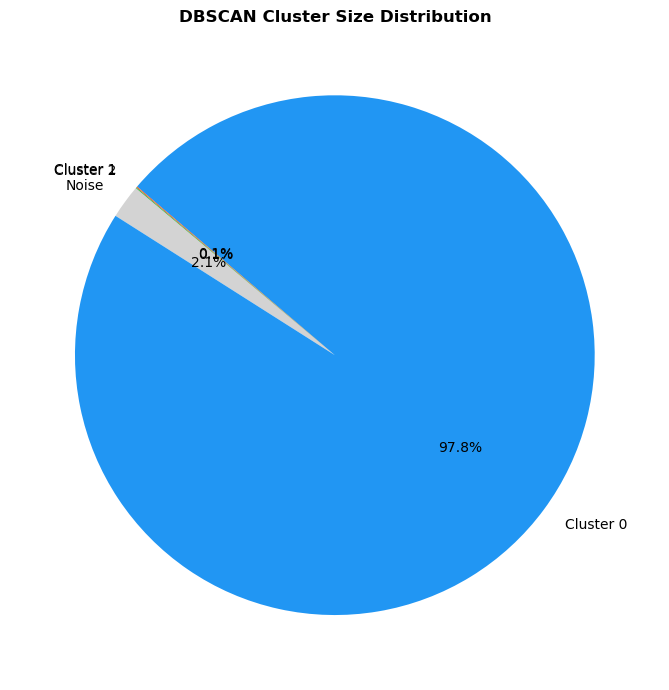

DBSCAN cluster sizes saved ✓


In [9]:
# cluster sizes pie (noise included)
palette = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']
sizes = pd.Series(cluster_labels).value_counts().sort_index()
labels_pie = ['Noise' if i == -1 else f'Cluster {i}' for i in sizes.index]
colors_pie = ['lightgrey'] + [palette[i % len(palette)] for i in range(len(sizes)-1)]

plt.figure(figsize=(7, 7))
plt.pie(sizes.values, labels=labels_pie, autopct='%1.1f%%',
        colors=colors_pie, startangle=140)
plt.title('DBSCAN Cluster Size Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/dbscan_cluster_sizes.png', dpi=150, bbox_inches='tight')
plt.show()
print("DBSCAN cluster sizes saved ✓")

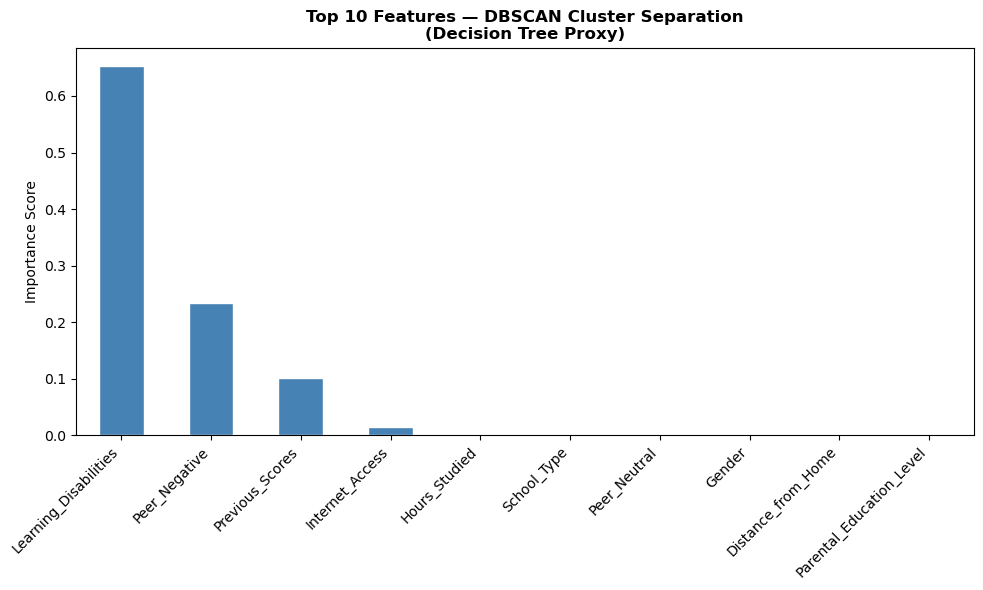

Top 5 most important features:
Learning_Disabilities    0.652779
Peer_Negative            0.233550
Previous_Scores          0.100093
Internet_Access          0.013578
Hours_Studied            0.000000
dtype: float64

Decision Tree reproduced 100.0% of DBSCAN assignments

DBSCAN CLUSTERING - FINAL SUMMARY
Algorithm:         DBSCAN
eps:               4.0
min_samples:       4
Clusters found:    3
Noise points:      139 (2.1%)
Silhouette Score:  N/A (degenerate clusters)
Davies-Bouldin:    N/A (degenerate clusters)
Calinski-Harabasz: N/A (degenerate clusters)
ANOVA:             N/A (degenerate clusters)

Conclusion: Despite extensive parameter tuning,
DBSCAN produced a severely imbalanced distribution
(6460/4/4) confirms it is unsuitable for this
dataset. Documented as limitation.

Metrics saved: data/metrics_dbscan.csv


In [10]:
mask = cluster_labels != -1
X_clean = X_array[mask]
labels_clean = cluster_labels[mask]

dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_clean, labels_clean)

importances = pd.Series(dt.feature_importances_,
                        index=X_scaled.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.head(10).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 10 Features — DBSCAN Cluster Separation\n(Decision Tree Proxy)',
          fontweight='bold')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('plots/dbscan_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 most important features:")
print(importances.head())
importances.to_csv('data/dbscan_feature_importance.csv', header=['Importance'])

acc = accuracy_score(labels_clean, dt.predict(X_clean))
print(f"\nDecision Tree reproduced {acc*100:.1f}% of DBSCAN assignments")

print("\n" + "=" * 55)
print("DBSCAN CLUSTERING - FINAL SUMMARY")
print("=" * 55)
print(f"Algorithm:         DBSCAN")
print(f"eps:               {EPS}")
print(f"min_samples:       {MIN_SAMPLES}")
print(f"Clusters found:    {n_clusters}")
print(f"Noise points:      {n_noise} ({noise_ratio:.1f}%)")
print(f"Silhouette Score:  N/A (degenerate clusters)")
print(f"Davies-Bouldin:    N/A (degenerate clusters)")
print(f"Calinski-Harabasz: N/A (degenerate clusters)")
print(f"ANOVA:             N/A (degenerate clusters)")
print(f"\nConclusion: Despite extensive parameter tuning,")
print(f"DBSCAN produced a severely imbalanced distribution")
print(f"(6460/4/4) confirms it is unsuitable for this")
print(f"dataset. Documented as limitation.")
print(f"\nMetrics saved: data/metrics_dbscan.csv")
print("=" * 55)